In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [81]:
df = pd.read_csv("ML_dataset2.csv")
df.head()

,Country,Year,Precipitation,River Flow,Soil Water,Surface Water,Terr Water Storage,Vegetation Avg,Water Bodies,Avg Temp,Water Stress,Population Growth,Freshwater Resources,GDP,Overall Water Withdrawals,Dom Wuthdrawls,Political Violence
0,Algeria,2001,52.0,22.998,0.100000,NaN,NaN,0.117250,2099.032,24.18333,81.71,1.373291,358.971009,1776.949446,51.633028,31.40793,155.0
1,Algeria,2002,61.0,20.755,0.103333,NaN,-1.000000,0.115583,1835.018,23.87500,85.04,1.330395,354.226905,1751.911234,53.735272,31.96875,210.0
2,Algeria,2003,99.0,23.075,0.107500,0.000121,2.333333,0.120667,2119.552,23.85833,87.52,1.329615,349.548223,1793.094603,55.305819,32.48746,158.0
3,Algeria,2004,94.0,21.668,0.107500,0.000125,3.000000,0.122333,2149.398,23.51667,90.01,1.396440,344.700914,2116.689481,56.876366,32.96862,96.0
4,Algeria,2005,73.0,21.193,0.105833,0.000080,-6.500000,0.120083,1926.585,23.88333,92.49,1.463309,339.693600,2627.289243,58.446912,33.41618,78.0


In [82]:
df.dtypes

Country                       object
Year                           int64
Precipitation                float64
River Flow                    object
Soil Water                   float64
Surface Water                float64
Terr Water Storage           float64
Vegetation Avg               float64
Water Bodies                 float64
Avg Temp                     float64
Water Stress                 float64
Population Growth            float64
Freshwater Resources         float64
GDP                          float64
Overall Water Withdrawals    float64
Dom Wuthdrawls               float64
Political Violence           float64
dtype: object

In [83]:
df.isna().sum()

Country                        0
Year                           0
Precipitation                 25
River Flow                   400
Soil Water                   126
Surface Water                108
Terr Water Storage           174
Vegetation Avg                 0
Water Bodies                 287
Avg Temp                      54
Water Stress                 214
Population Growth             79
Freshwater Resources         250
GDP                          171
Overall Water Withdrawals    207
Dom Wuthdrawls               286
Political Violence           197
dtype: int64

In [84]:
df["Country"].unique()

array(['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso',
       'Burundi', 'Cabo Verde (Cape Verde)', 'Cameroon',
       'Central African Republic', 'Chad', 'Comoros',
       'Democratic Republic of the Congo', 'Republic of the Congo',
       'Djibouti', 'Egypt', 'Equatorial Guinea', 'Eritrea',
       'Eswatini (formerly Swaziland)', 'Ethiopia', 'Gabon', 'Gambia',
       'Ghana', 'Guinea', 'Guinea-Bissau', "Ivory Coast (Côte d'Ivoire)",
       'Kenya', 'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi',
       'Mali', 'Mauritania', 'Mauritius', 'Morocco', 'Mozambique',
       'Namibia', 'Niger', 'Nigeria', 'Rwanda', 'Sao Tome and Principe',
       'Senegal', 'Seychelles', 'Sierra Leone', 'Somalia', 'South Africa',
       'South Sudan', 'Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda',
       'Zambia', 'Zimbabwe'], dtype=object)

In [85]:
df["Country"]=df["Country"].str.replace("Eswatini (formerly Swaziland)", "Eswatini")
df["Country"]=df["Country"].str.replace("Cabo Verde (Cape Verde)", "Cabo Verde")
df["Country"]=df["Country"].str.replace("Ivory Coast (Côte d'Ivoire)", "Ivory Coast")

In [86]:
df["Country"].unique()

array(['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso',
       'Burundi', 'Cabo Verde', 'Cameroon', 'Central African Republic',
       'Chad', 'Comoros', 'Democratic Republic of the Congo',
       'Republic of the Congo', 'Djibouti', 'Egypt', 'Equatorial Guinea',
       'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana',
       'Guinea', 'Guinea-Bissau', 'Ivory Coast', 'Kenya', 'Lesotho',
       'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania',
       'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger',
       'Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal',
       'Seychelles', 'Sierra Leone', 'Somalia', 'South Africa',
       'South Sudan', 'Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda',
       'Zambia', 'Zimbabwe'], dtype=object)

In [87]:
df = df.dropna(how="all")
df.shape

(1350, 17)

In [88]:
df.describe(include=["float", "category"])

,Precipitation,Soil Water,Surface Water,Terr Water Storage,Vegetation Avg,Water Bodies,Avg Temp,Water Stress,Population Growth,Freshwater Resources,GDP,Overall Water Withdrawals,Dom Wuthdrawls,Political Violence
count,1325.000000,1224.000000,1242.000000,1176.000000,1350.000000,1.063000e+03,1296.000000,1136.000000,1271.000000,1100.000000,1179.000000,1143.000000,1064.000000,1153.000000
mean,949.705660,0.593562,0.086673,88.359009,1.605493,2.887410e+06,24.627246,33.584049,2.347779,8223.587397,2356.216627,172.890769,31.335033,216.267997
std,670.614327,0.817105,0.322128,527.898556,2.299528,1.419243e+07,3.308077,109.108217,1.077832,16882.640331,3144.298820,961.711202,22.999864,576.867467
min,8.000000,0.080000,0.000000,-1655.000000,0.096250,1.241917e+01,11.691667,0.030000,-5.415910,8.879555,113.518420,0.020541,0.354241,0.000000
25%,332.000000,0.169167,0.000694,-16.250000,0.355958,3.193854e+02,22.597917,1.560000,1.754244,804.525612,551.389711,1.093750,11.142850,5.000000
50%,941.000000,0.225833,0.004634,12.708333,0.571167,5.172320e+03,25.183332,6.330000,2.497022,1505.017565,1067.382055,4.780858,25.254580,22.000000
75%,1322.000000,0.286042,0.021000,66.666667,1.362750,9.226176e+04,27.379167,21.985000,2.965461,6912.330737,2951.525701,21.555798,48.000000,133.000000
max,3197.000000,3.350000,2.315434,6562.000000,8.945000,9.256356e+07,29.966667,817.140000,6.410083,125230.129000,23473.521770,7750.000000,84.210530,5959.000000


In [89]:
df["River Flow"] = pd.to_numeric(df["River Flow"], errors='coerce')

In [90]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [91]:
print(df.columns.tolist())

['Country', 'Year', 'Precipitation', 'River Flow', 'Soil Water', 'Surface Water', 'Terr Water Storage', 'Vegetation Avg', 'Water Bodies', 'Avg Temp', 'Water Stress', 'Population Growth', 'Freshwater Resources', 'GDP', 'Overall Water Withdrawals', 'Dom Wuthdrawls', 'Political Violence']


In [92]:
FINAL_TEST_YEAR = 2025

test_df = df[df["Year"] == FINAL_TEST_YEAR].copy()
train_df = df[df["Year"] < FINAL_TEST_YEAR].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1296, 17)
Test shape: (54, 17)


In [127]:
categorical = df[["Country", "Year"]]
numerical = df[["Precipitation",
        "River Flow",       
        "Soil Water",
        "Surface Water",
        "Terr Water Storage",
        "Vegetation Avg",
        "Water Bodies",
        "Avg Temp",
        "GDP",
        "Freshwater Resources",
        "Political Violence",
        "Overall Water Withdrawals",
        "Dom Wuthdrawls"]]

In [128]:
feature_cols = ["Precipitation",
        "River Flow",       
        "Soil Water",
        "Surface Water",
        "Terr Water Storage",
        "Vegetation Avg",
        "Water Bodies",
        "Avg Temp",
        "GDP",
        "Freshwater Resources",
        "Political Violence",
        "Overall Water Withdrawals",
        "Dom Wuthdrawls"]    #Independent variables
target= "Population Growth"     #Dependent variable
print(df[target].shape)
print(df[feature_cols].shape)

(1271,)
(1271, 13)


In [129]:
print(df[feature_cols].dtypes)
print(df[feature_cols].isnull().sum())

Precipitation                float64
River Flow                   float64
Soil Water                   float64
Surface Water                float64
Terr Water Storage           float64
Vegetation Avg               float64
Water Bodies                 float64
Avg Temp                     float64
GDP                          float64
Freshwater Resources         float64
Political Violence           float64
Overall Water Withdrawals    float64
Dom Wuthdrawls               float64
dtype: object
Precipitation                0
River Flow                   0
Soil Water                   0
Surface Water                0
Terr Water Storage           0
Vegetation Avg               0
Water Bodies                 0
Avg Temp                     0
GDP                          0
Freshwater Resources         0
Political Violence           0
Overall Water Withdrawals    0
Dom Wuthdrawls               0
dtype: int64


In [130]:
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].mean())
print(df[feature_cols].isnull().sum())

Precipitation                0
River Flow                   0
Soil Water                   0
Surface Water                0
Terr Water Storage           0
Vegetation Avg               0
Water Bodies                 0
Avg Temp                     0
GDP                          0
Freshwater Resources         0
Political Violence           0
Overall Water Withdrawals    0
Dom Wuthdrawls               0
dtype: int64


In [131]:
print(df[target].isnull().sum())

0


## Regression droping nulls in Target

In [132]:
df = df.dropna(subset=["Population Growth"]) 
print(df["Population Growth"].isnull().sum())

0


In [133]:
X = df[target]
y = df[feature_cols]

In [134]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, random_state=42
)

In [135]:
years = sorted(df['Year'].unique())   # gets all unique years from your dataframe
initial_train_years = 3   
results = []

In [136]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

for i in range(initial_train_years, len(years)):
    train_years = years[:i]
    test_year   = years[i]

    train = df[df['Year'].isin(train_years)]
    test  = df[df['Year'] == test_year]

    X_train, y_train = train[feature_cols], train[target]
    X_test,  y_test  = test[feature_cols],  test[target]

    X_train = X_train[y_train.notna()]
    y_train = y_train.dropna()

    X_train = X_train.fillna(X_train.mean())
    X_test  = X_test.fillna(X_train.mean())  # important

    mask = y_test.notna().values
    if mask.sum() == 0:
        print(f"Skipping {test_year} — no valid target values")
        continue

    if len(y_train) < 2:
        print(f"Skipping {test_year} — not enough training data")
        continue
    
    model = LinearRegression()
    model.fit(X_train, y_train)

    preds  = model.predict(X_test)
    y_true = y_test[mask]
    y_pred = preds[mask]

    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    results.append({'Test Year': test_year, 'R2': round(r2, 4), 'RMSE': round(rmse, 4)})
    print(f"Train up to {train_years[-1]} -> Test {test_year} | R2: {r2:.4f} | RMSE: {rmse:.4f}")

results_df = pd.DataFrame(results)
print("\n", results_df)

Train up to 2003 -> Test 2004 | R2: 0.3464 | RMSE: 0.9637
Train up to 2004 -> Test 2005 | R2: 0.3907 | RMSE: 0.8789
Train up to 2005 -> Test 2006 | R2: 0.3537 | RMSE: 0.8701
Train up to 2006 -> Test 2007 | R2: 0.3248 | RMSE: 0.8608
Train up to 2007 -> Test 2008 | R2: 0.2500 | RMSE: 0.8283
Train up to 2008 -> Test 2009 | R2: 0.2134 | RMSE: 0.9848
Train up to 2009 -> Test 2010 | R2: 0.2406 | RMSE: 0.9542
Train up to 2010 -> Test 2011 | R2: 0.3087 | RMSE: 1.1567
Train up to 2011 -> Test 2012 | R2: 0.3309 | RMSE: 0.9731
Train up to 2012 -> Test 2013 | R2: 0.0584 | RMSE: 0.8884
Train up to 2013 -> Test 2014 | R2: 0.1566 | RMSE: 0.9175
Train up to 2014 -> Test 2015 | R2: 0.1349 | RMSE: 0.9701
Train up to 2015 -> Test 2016 | R2: 0.1025 | RMSE: 1.0709
Train up to 2016 -> Test 2017 | R2: 0.0630 | RMSE: 1.3508
Train up to 2017 -> Test 2018 | R2: 0.1038 | RMSE: 0.9322
Train up to 2018 -> Test 2019 | R2: 0.1795 | RMSE: 0.7652
Train up to 2019 -> Test 2020 | R2: 0.1767 | RMSE: 0.7366
Train up to 20

In [137]:
print(X_train.shape)
print(X_test.shape)

(1218, 13)
(53, 13)


In [138]:
print(X_train.isna().sum())
print(y_train.isna().sum())

Precipitation                0
River Flow                   0
Soil Water                   0
Surface Water                0
Terr Water Storage           0
Vegetation Avg               0
Water Bodies                 0
Avg Temp                     0
GDP                          0
Freshwater Resources         0
Political Violence           0
Overall Water Withdrawals    0
Dom Wuthdrawls               0
dtype: int64
0


In [139]:
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  
y_train = y_train.fillna(y_train.mean())
y_test = y_test.fillna(y_test.mean())

In [140]:
print(X_train.isna().sum())
print(y_train.isna().sum())

Precipitation                0
River Flow                   0
Soil Water                   0
Surface Water                0
Terr Water Storage           0
Vegetation Avg               0
Water Bodies                 0
Avg Temp                     0
GDP                          0
Freshwater Resources         0
Political Violence           0
Overall Water Withdrawals    0
Dom Wuthdrawls               0
dtype: int64
0


In [141]:
model = LinearRegression()

In [142]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [143]:
y_pred = model.predict(X_test)

In [144]:
print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)
print("y_test type:", type(y_test))
print("y_pred type:", type(y_pred))
print("y_test nulls:", y_test.isna().sum())

y_test shape: (53,)
y_pred shape: (53,)
y_test type: <class 'pandas.core.series.Series'>
y_pred type: <class 'numpy.ndarray'>
y_test nulls: 0


In [145]:
# Checking where the nulls are coming from
print("Nulls in Target Column", df[target].isna().sum())          
print("Nulls in test year:", df[df['Year'] == test_year][target].isna().sum())  

Nulls in Target Column 0
Nulls in test year: 0


In [146]:
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error

# 1. Fit on training data
X_train_const = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_const).fit()

# 2. Get p-values from training fit
print(ols_model.summary())

# 3. Evaluate on test data
X_test_const = sm.add_constant(X_test, has_constant='add')
y_pred = ols_model.predict(X_test_const)

print("R² score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

                            OLS Regression Results                            
Dep. Variable:      Population Growth   R-squared:                       0.283
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     36.55
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           7.42e-78
Time:                        13:56:44   Log-Likelihood:                -1623.8
No. Observations:                1218   AIC:                             3276.
Df Residuals:                    1204   BIC:                             3347.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [169]:
# Results are statistically significant, as p-value < .05
# Population Growth can be explained by ~6% of the variance in other variables. 
# High MSE (~7656)

In [151]:
num_cols = df.drop(columns=["Country", "Year"]).columns
df[num_cols].corr()

,Precipitation,River Flow,Soil Water,Surface Water,Terr Water Storage,Vegetation Avg,Water Bodies,Avg Temp,Water Stress,Population Growth,Freshwater Resources,GDP,Overall Water Withdrawals,Dom Wuthdrawls,Political Violence
Precipitation,1.000000,-0.100180,0.003580,0.122228,0.035703,0.247821,0.072904,0.101752,-0.297475,0.219620,0.551507,0.049176,-0.225739,0.340107,-0.134531
River Flow,-0.100180,1.000000,0.345755,-0.044572,0.181190,0.241104,-0.052920,0.209549,-0.072598,0.067214,-0.053071,-0.033752,0.008278,-0.088455,0.251363
Soil Water,0.003580,0.345755,1.000000,0.462040,0.267368,0.685295,0.388495,-0.132364,-0.116262,0.030059,-0.113612,-0.126149,-0.098974,-0.221051,-0.018094
Surface Water,0.122228,-0.044572,0.462040,1.000000,0.038559,0.436434,0.886069,-0.131564,-0.046225,-0.010371,-0.073355,-0.051065,-0.040584,-0.088819,-0.063458
Terr Water Storage,0.035703,0.181190,0.267368,0.038559,1.000000,0.200012,-0.045988,-0.007891,-0.039132,0.016920,-0.053027,-0.020455,-0.023939,0.057003,0.181412
Vegetation Avg,0.247821,0.241104,0.685295,0.436434,0.200012,1.000000,0.237149,-0.041670,-0.138637,-0.026801,-0.033004,-0.059380,-0.105564,-0.145629,0.028378
Water Bodies,0.072904,-0.052920,0.388495,0.886069,-0.045988,0.237149,1.000000,-0.105909,-0.042693,0.056850,-0.038052,-0.088543,-0.036855,-0.048740,-0.041863
Avg Temp,0.101752,0.209549,-0.132364,-0.131564,-0.007891,-0.041670,-0.105909,1.000000,-0.131553,0.345210,0.104468,-0.129361,-0.020151,0.125627,0.144824
Water Stress,-0.297475,-0.072598,-0.116262,-0.046225,-0.039132,-0.138637,-0.042693,-0.131553,1.000000,-0.201942,-0.137239,0.333939,0.225441,-0.193088,0.087612
Population Growth,0.219620,0.067214,0.030059,-0.010371,0.016920,-0.026801,0.056850,0.345210,-0.201942,1.000000,0.166105,-0.240585,-0.064314,-0.073865,-0.022480


In [152]:
# Multicolinearity issues with : 
# Soil Water vs Vegetation Avg ~.82
# Water bodies vs Surface Water ~.96
# Fresh water resources vs precipitation ~.57 (okay, but be aware)

In [153]:
print(df["Population Growth"].unique())

[1.373291 1.330395 1.329615 ... 1.706209 1.677096 1.780482]


In [154]:
# Stick with linear regression, since result is continous

<Axes: >

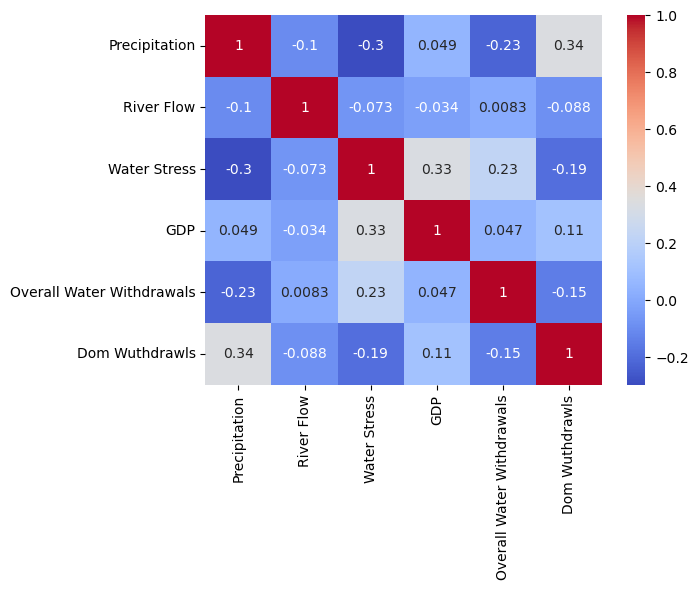

In [155]:
# Trying Random Forest for better R-squared
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Drop insignificant features
X = df[["Precipitation", "River Flow", "Water Stress",
        "GDP", "Overall Water Withdrawals", "Dom Wuthdrawls"]]

# Check multicollinearity
import seaborn as sns
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")

In [156]:
# No multicolinearity issues, after insignificant independent variables are dropped.

In [157]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())
y_train = y_train.fillna(y_train.mean())
y_test = y_test.fillna(y_train.mean())  # ← add this line, use y_train mean

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.857246586500788
RMSE: 1451398.13651558


In [158]:
# High R-square, and high RMSE

Water Stress                 0.425618
Dom Wuthdrawls               0.189581
Precipitation                0.164788
GDP                          0.112419
Overall Water Withdrawals    0.058895
River Flow                   0.048700
dtype: float64


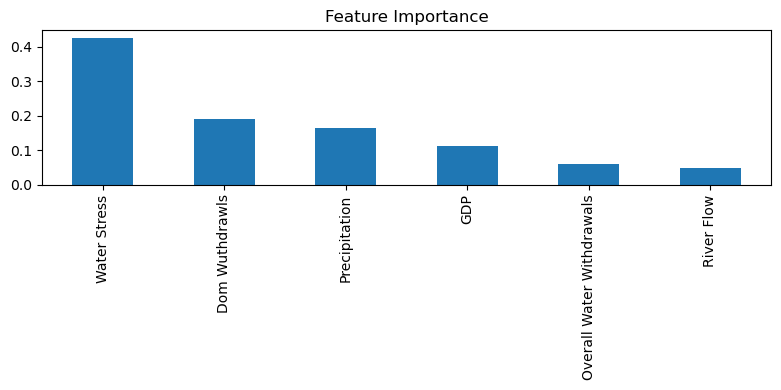

In [159]:
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance)

importance.plot(kind='bar', figsize=(8,4), title='Feature Importance')
plt.tight_layout()
plt.show()

## Regression, filling Target nulls

In [160]:
df[target] = df[target].fillna(df[target].mean())
print(df[target].isnull().sum())

0


In [161]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

for i in range(initial_train_years, len(years)):
    train_years = years[:i]
    test_year   = years[i]

    train = df[df['Year'].isin(train_years)]
    test  = df[df['Year'] == test_year]

    X_train, y_train = train[feature_cols], train[target]
    X_test,  y_test  = test[feature_cols],  test[target]

    X_train = X_train[y_train.notna()]
    y_train = y_train.dropna()

    X_train = X_train.fillna(X_train.mean())
    X_test  = X_test.fillna(X_train.mean())  # important

    mask = y_test.notna().values
    if mask.sum() == 0:
        print(f"Skipping {test_year} — no valid target values")
        continue

    if len(y_train) < 2:
        print(f"Skipping {test_year} — not enough training data")
        continue
    
    model = LinearRegression()
    model.fit(X_train, y_train)

    preds  = model.predict(X_test)
    y_true = y_test[mask]
    y_pred = preds[mask]

    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    results.append({'Test Year': test_year, 'R2': round(r2, 4), 'RMSE': round(rmse, 4)})
    print(f"Train up to {train_years[-1]} -> Test {test_year} | R2: {r2:.4f} | RMSE: {rmse:.4f}")

results_df = pd.DataFrame(results)
print("\n", results_df)

Train up to 2003 -> Test 2004 | R2: 0.3464 | RMSE: 0.9637
Train up to 2004 -> Test 2005 | R2: 0.3907 | RMSE: 0.8789
Train up to 2005 -> Test 2006 | R2: 0.3537 | RMSE: 0.8701
Train up to 2006 -> Test 2007 | R2: 0.3248 | RMSE: 0.8608
Train up to 2007 -> Test 2008 | R2: 0.2500 | RMSE: 0.8283
Train up to 2008 -> Test 2009 | R2: 0.2134 | RMSE: 0.9848
Train up to 2009 -> Test 2010 | R2: 0.2406 | RMSE: 0.9542
Train up to 2010 -> Test 2011 | R2: 0.3087 | RMSE: 1.1567
Train up to 2011 -> Test 2012 | R2: 0.3309 | RMSE: 0.9731
Train up to 2012 -> Test 2013 | R2: 0.0584 | RMSE: 0.8884
Train up to 2013 -> Test 2014 | R2: 0.1566 | RMSE: 0.9175
Train up to 2014 -> Test 2015 | R2: 0.1349 | RMSE: 0.9701
Train up to 2015 -> Test 2016 | R2: 0.1025 | RMSE: 1.0709
Train up to 2016 -> Test 2017 | R2: 0.0630 | RMSE: 1.3508
Train up to 2017 -> Test 2018 | R2: 0.1038 | RMSE: 0.9322
Train up to 2018 -> Test 2019 | R2: 0.1795 | RMSE: 0.7652
Train up to 2019 -> Test 2020 | R2: 0.1767 | RMSE: 0.7366
Train up to 20

In [162]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [163]:
y_pred = model.predict(X_test)

In [164]:
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error

# 1. Fit on training data
X_train_const = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_const).fit()

# 2. Get p-values from training fit
print(ols_model.summary())

# 3. Evaluate on test data
X_test_const = sm.add_constant(X_test, has_constant='add')
y_pred = ols_model.predict(X_test_const)

print("R² score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

                            OLS Regression Results                            
Dep. Variable:      Population Growth   R-squared:                       0.283
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     36.55
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           7.42e-78
Time:                        13:57:25   Log-Likelihood:                -1623.8
No. Observations:                1218   AIC:                             3276.
Df Residuals:                    1204   BIC:                             3347.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [168]:
#Low r-squared
# soemwhat high MSE

In [165]:
df[num_cols].corr()

,Precipitation,River Flow,Soil Water,Surface Water,Terr Water Storage,Vegetation Avg,Water Bodies,Avg Temp,Water Stress,Population Growth,Freshwater Resources,GDP,Overall Water Withdrawals,Dom Wuthdrawls,Political Violence
Precipitation,1.000000,-0.100180,0.003580,0.122228,0.035703,0.247821,0.072904,0.101752,-0.297475,0.219620,0.551507,0.049176,-0.225739,0.340107,-0.134531
River Flow,-0.100180,1.000000,0.345755,-0.044572,0.181190,0.241104,-0.052920,0.209549,-0.072598,0.067214,-0.053071,-0.033752,0.008278,-0.088455,0.251363
Soil Water,0.003580,0.345755,1.000000,0.462040,0.267368,0.685295,0.388495,-0.132364,-0.116262,0.030059,-0.113612,-0.126149,-0.098974,-0.221051,-0.018094
Surface Water,0.122228,-0.044572,0.462040,1.000000,0.038559,0.436434,0.886069,-0.131564,-0.046225,-0.010371,-0.073355,-0.051065,-0.040584,-0.088819,-0.063458
Terr Water Storage,0.035703,0.181190,0.267368,0.038559,1.000000,0.200012,-0.045988,-0.007891,-0.039132,0.016920,-0.053027,-0.020455,-0.023939,0.057003,0.181412
Vegetation Avg,0.247821,0.241104,0.685295,0.436434,0.200012,1.000000,0.237149,-0.041670,-0.138637,-0.026801,-0.033004,-0.059380,-0.105564,-0.145629,0.028378
Water Bodies,0.072904,-0.052920,0.388495,0.886069,-0.045988,0.237149,1.000000,-0.105909,-0.042693,0.056850,-0.038052,-0.088543,-0.036855,-0.048740,-0.041863
Avg Temp,0.101752,0.209549,-0.132364,-0.131564,-0.007891,-0.041670,-0.105909,1.000000,-0.131553,0.345210,0.104468,-0.129361,-0.020151,0.125627,0.144824
Water Stress,-0.297475,-0.072598,-0.116262,-0.046225,-0.039132,-0.138637,-0.042693,-0.131553,1.000000,-0.201942,-0.137239,0.333939,0.225441,-0.193088,0.087612
Population Growth,0.219620,0.067214,0.030059,-0.010371,0.016920,-0.026801,0.056850,0.345210,-0.201942,1.000000,0.166105,-0.240585,-0.064314,-0.073865,-0.022480


<Axes: >

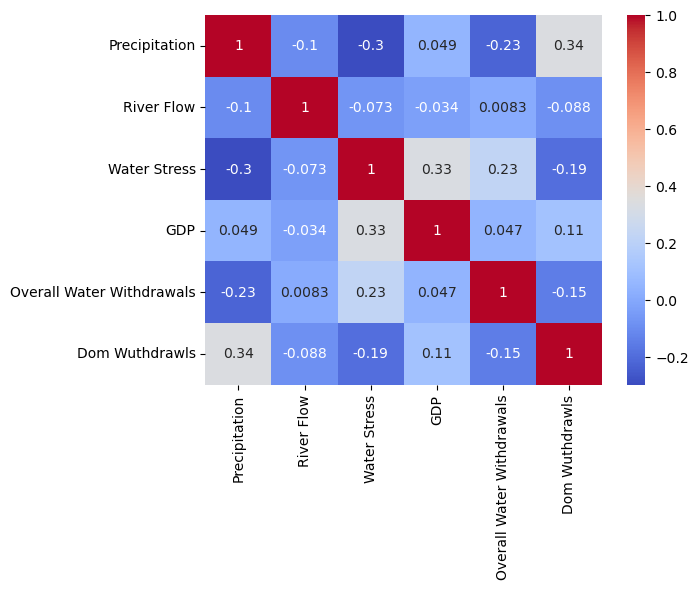

In [166]:
# Trying Random Forest for better R-squared
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Drop insignificant features
X = df[["Precipitation", "River Flow", "Water Stress",
        "GDP", "Overall Water Withdrawals", "Dom Wuthdrawls"]]

# Check multicollinearity
import seaborn as sns
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")

In [167]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())
y_train = y_train.fillna(y_train.mean())
y_test = y_test.fillna(y_train.mean())  # ← add this line, use y_train mean

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.857246586500788
RMSE: 1451398.13651558
